# Phase 3 — Modeling

Three models of increasing complexity are trained on the engineered features:

| # | Model | Type | Handles imbalance via |
|---|-------|------|-----------------------|
| 1 | Logistic Regression | Linear | `class_weight` |
| 2 | Random Forest | Ensemble / tree | `class_weight` |
| 3 | LSTM | Deep learning / sequence | `WeightedRandomSampler` + `BCEWithLogitsLoss(pos_weight)` |

All models predict `handover_soon` (binary classification).

In [1]:
import sys, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, torch
from pathlib import Path

from src.models import (
    load_splits, xy, pos_weight,
    LSTMClassifier, SequenceDataset, SEQ_LEN
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

MODELS_DIR = Path('../models')

train, val, test, feat_cols, meta = load_splits()
X_train, y_train = xy(train, feat_cols)
X_val,   y_val   = xy(val,   feat_cols)
X_test,  y_test  = xy(test,  feat_cols)

print(f'Features : {len(feat_cols)}')
print(f'Train    : {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Pos weight (neg/pos ratio): {pos_weight(y_train):.1f}x')

Features : 64
Train    : 18,855 | Val: 4,050 | Test: 4,050
Pos weight (neg/pos ratio): 37.8x


## Model 1 — Logistic Regression

A linear classifier with L2 regularisation (C = 0.5).  
Each feature gets one coefficient — easy to interpret but cannot capture signal interactions.

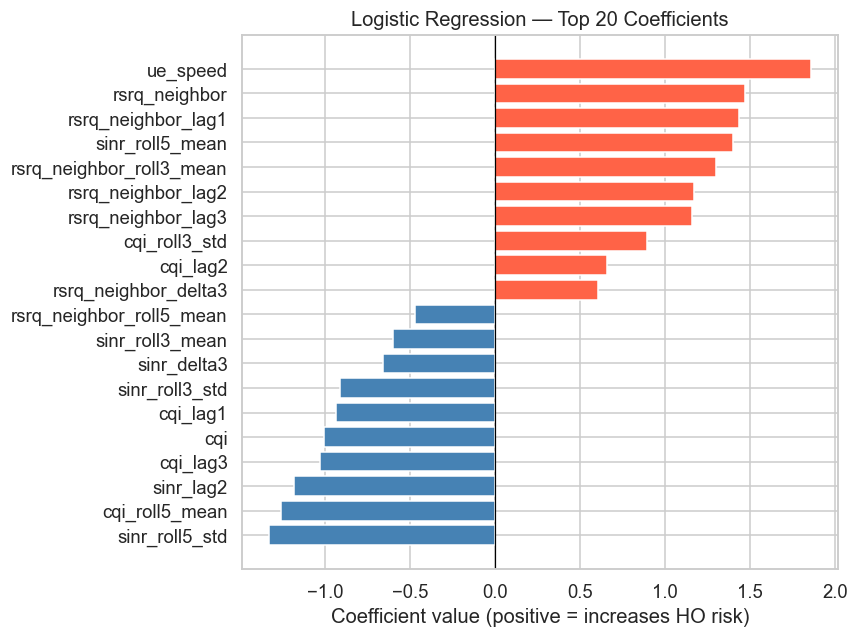

In [2]:
lr = joblib.load(MODELS_DIR / 'logistic_regression.pkl')

# Top coefficients
coef_df = pd.DataFrame({'feature': feat_cols, 'coef': lr.coef_[0]})
top_pos = coef_df.nlargest(10, 'coef')
top_neg = coef_df.nsmallest(10, 'coef')
top = pd.concat([top_pos, top_neg]).sort_values('coef')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient value (positive = increases HO risk)')
ax.set_title('Logistic Regression — Top 20 Coefficients')
plt.tight_layout(); plt.show()

## Model 2 — Random Forest

300 decision trees, max depth 12, balanced class weights.  
Feature importances (mean impurity decrease) reveal which engineered features matter most.

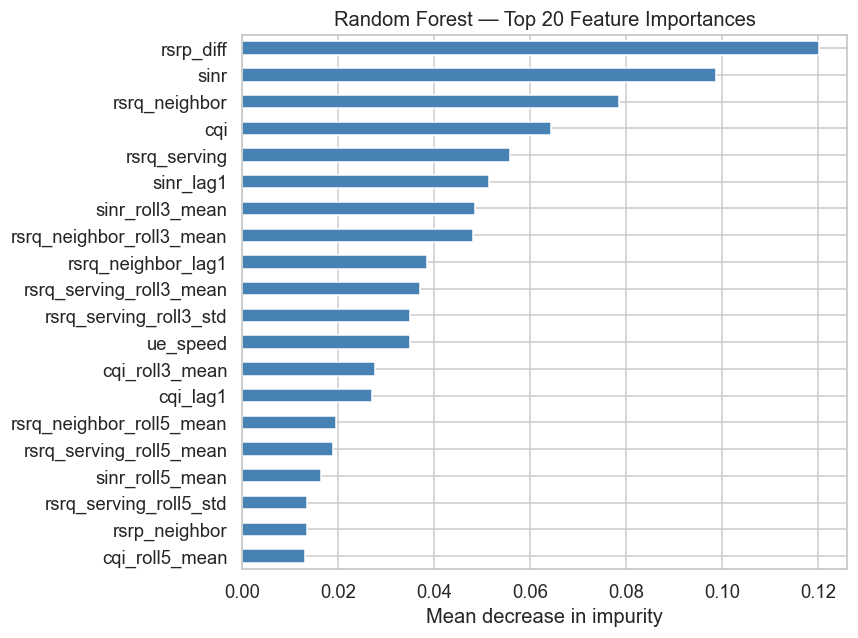

In [3]:
rf = joblib.load(MODELS_DIR / 'random_forest.pkl')

importances = pd.Series(rf.feature_importances_, index=feat_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout(); plt.show()

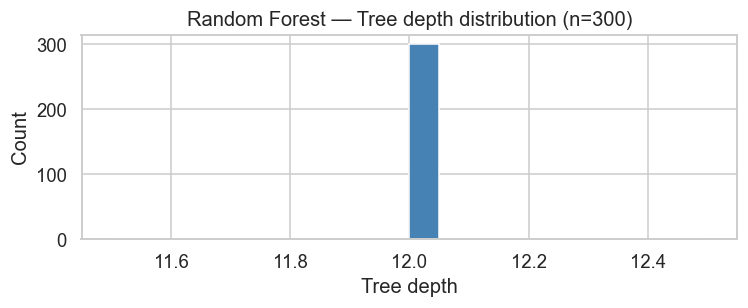

In [4]:
# Distribution of tree depths in the forest
depths = [t.get_depth() for t in rf.estimators_]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(depths, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('Tree depth'); ax.set_ylabel('Count')
ax.set_title(f'Random Forest — Tree depth distribution (n={len(rf.estimators_)})')
plt.tight_layout(); plt.show()

## Model 3 — LSTM

Architecture: **2-layer LSTM (64 hidden units)** → Linear(64→32) → ReLU → Dropout → Linear(32→1)

Each sample is a **sequence of 10 consecutive timesteps** for a single UE.  
This lets the model capture the degrading-RSRP trend before a handover fires.

In [5]:
lstm = LSTMClassifier(input_size=len(feat_cols))
lstm.load_state_dict(torch.load(MODELS_DIR / 'lstm.pt', map_location='cpu'))
lstm.eval()

total_params = sum(p.numel() for p in lstm.parameters())
trainable    = sum(p.numel() for p in lstm.parameters() if p.requires_grad)
print(lstm)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

LSTMClassifier(
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters    : 68,673
Trainable parameters: 68,673


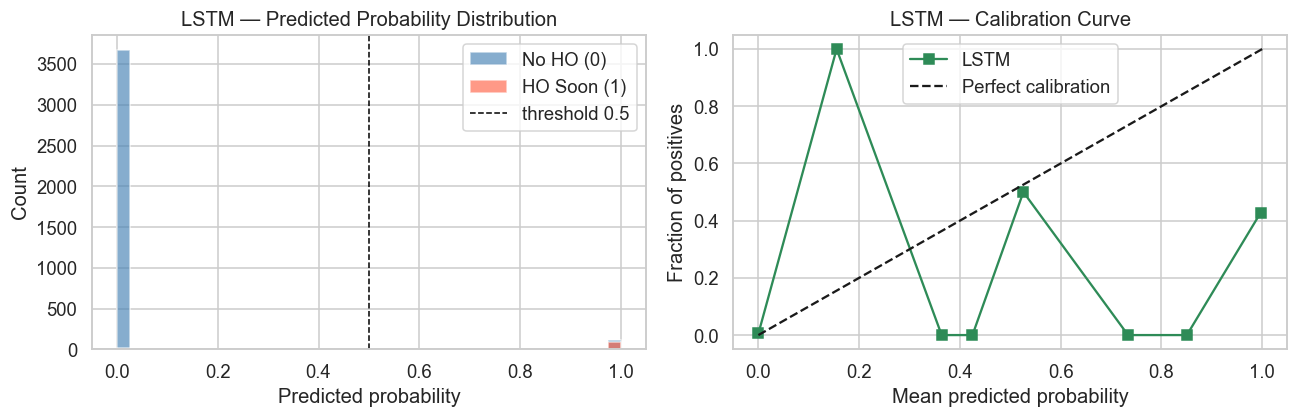

In [6]:
# Visualise predicted probability distribution on test set
ds   = SequenceDataset(test, feat_cols, seq_len=SEQ_LEN)
loader = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=False)

probs, labels = [], []
with torch.no_grad():
    for xb, yb in loader:
        probs.extend(torch.sigmoid(lstm(xb)).numpy())
        labels.extend(yb.numpy().astype(int))

probs  = np.array(probs)
labels = np.array(labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, color, name in [(0, 'steelblue', 'No HO (0)'), (1, 'tomato', 'HO Soon (1)')]:
    axes[0].hist(probs[labels == cls], bins=40, alpha=0.65,
                 color=color, label=name, edgecolor='white')
axes[0].axvline(0.5, ls='--', color='black', lw=1, label='threshold 0.5')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Count')
axes[0].set_title('LSTM — Predicted Probability Distribution')
axes[0].legend()

# Calibration (reliability diagram)
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(labels, probs, n_bins=10)
axes[1].plot(mean_pred, frac_pos, 's-', label='LSTM', color='seagreen')
axes[1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('LSTM — Calibration Curve'); axes[1].legend()

plt.tight_layout(); plt.show()

## Model Comparison — Probability Histograms

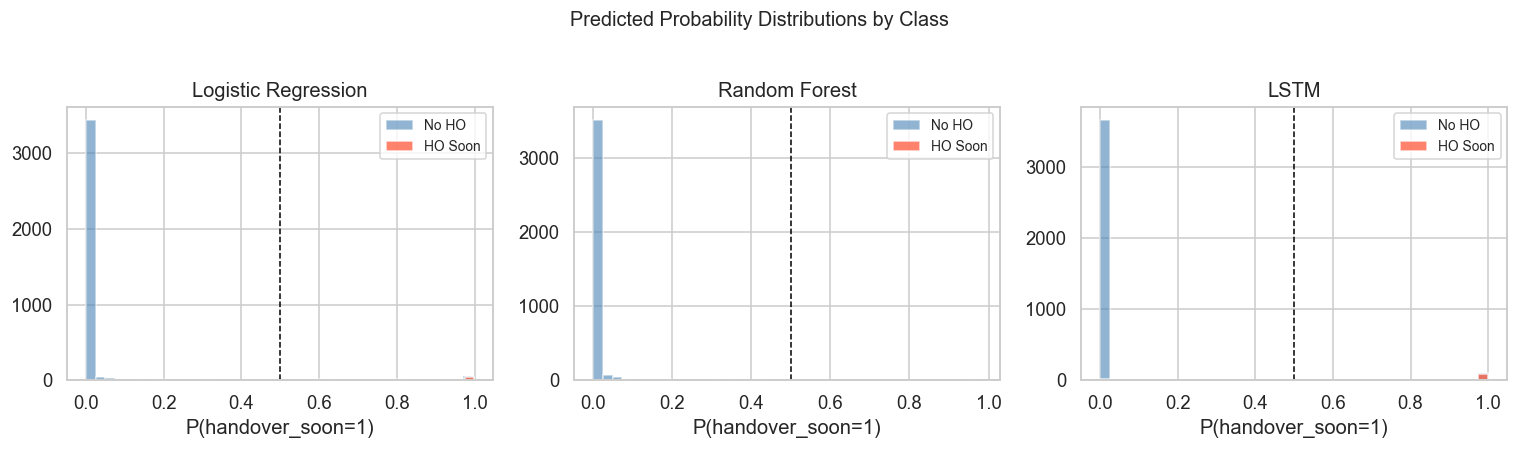

In [7]:
lr_probs  = lr.predict_proba(X_test)[:, 1]
rf_probs  = rf.predict_proba(X_test)[:, 1]
# LSTM probs already computed above (from SequenceDataset — slightly smaller test set)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
configs = [
    ('Logistic Regression', lr_probs, y_test, 'steelblue'),
    ('Random Forest',       rf_probs, y_test, 'darkorange'),
    ('LSTM',                probs,    labels,  'seagreen'),
]
for ax, (name, p, y, c) in zip(axes, configs):
    ax.hist(p[y == 0], bins=40, alpha=0.6, label='No HO',   color='steelblue', edgecolor='white')
    ax.hist(p[y == 1], bins=40, alpha=0.8, label='HO Soon', color='tomato',    edgecolor='white')
    ax.axvline(0.5, ls='--', color='black', lw=1)
    ax.set_title(name); ax.set_xlabel('P(handover_soon=1)')
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distributions by Class', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## Summary

| Model | Handles non-linearity | Uses temporal context | Interpretable |
|---|---|---|---|
| Logistic Regression | ✗ | Via lag features | ✓ (coefficients) |
| Random Forest | ✓ | Via lag features | ✓ (importances) |
| LSTM | ✓ | ✓ (native sequences) | ✗ |

→ **Next:** [04_evaluation.ipynb](04_evaluation.ipynb)